In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "../third_party")))

In [2]:
import os
os.environ["OPENAI_API_KEY"] = "sk-proj-1234567890"
import json
import torch
import numpy as np
import matplotlib
# Use interactive backend in notebooks; otherwise use 'Agg' for scripts
def _running_in_notebook():
    try:
        from IPython import get_ipython
        ip = get_ipython()
        if ip is None:
            return False
        return 'IPKernelApp' in ip.config
    except Exception:
        return False

if not _running_in_notebook():
    matplotlib.use('Agg')

import matplotlib.pyplot as plt
from PIL import Image
import sys
import random
from datetime import datetime
from typing import Any, Dict, List, Optional, Tuple
import math
import copy
from tqdm import tqdm

## SAM2 images
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "../third_party/video-sam2")))
from sam2.build_sam import build_sam2, build_sam2_video_predictor
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator
from sam2.build_sam import build_sam2_video_predictor
import cv2
import argparse

# Grounding Dino APIs
from groundingdino.util.inference import Model as gd_Model
from groundingdino.util.inference import load_image as load_gd_image
from groundingdino.util.utils import get_phrases_from_posmap

from laser.preprocess.mask_generation_grounding_dino import generate_masks_grounding_dino, get_frames, vidwrite 
from laser.preprocess.mask_generation import gen_video_masks
from laser.loading import load_video

* 'schema_extra' has been renamed to 'json_schema_extra'


In [3]:
try:
    get_ipython()
    get_ipython().run_line_magic('matplotlib', 'widget')
except Exception:
    try:
        get_ipython().run_line_magic('matplotlib', 'inline')
    except Exception:
        pass

In [4]:
from pathlib import Path, PurePath
# Resolve project root (looks for 'third_party' or 'laser' folder) and set expected third_party paths

def find_project_root(start=Path.cwd()):
    cur = start.resolve()
    for _ in range(8):
        if (cur / 'third_party').exists() or (cur / 'laser').exists():
            return cur
        if cur.parent == cur:
            break
        cur = cur.parent
    return start.resolve()

PROJECT_ROOT = find_project_root()
print('PROJECT_ROOT:', PROJECT_ROOT)

# data dir (fall back if not present)
DATA_DIR = (PROJECT_ROOT / 'data').resolve()

# third_party locations (where you downloaded checkpoints)
sam_dir = PROJECT_ROOT / 'third_party' / 'video-sam2'
sam_checkpoint_dir = sam_dir / 'checkpoints'
# prefer configs under third_party if present, else under data/sam2/configs
sam_config_candidates = [PROJECT_ROOT / 'third_party' / 'video-sam2' / 'configs', PROJECT_ROOT / 'data' / 'sam2' / 'configs']
sam_config_dir = next((p for p in sam_config_candidates if p.exists()), sam_config_candidates[0])

gd_dir = PROJECT_ROOT / 'third_party' / 'GroundingDINO'
gd_checkpoint_dir = gd_dir / 'checkpoints'
gd_config_dir = gd_dir / 'groundingdino' / 'config'

# Helpful prints and checks
print('sam_dir:', sam_dir)
print('sam_checkpoint_dir:', sam_checkpoint_dir)
print('sam_config_dir:', sam_config_dir)
print('gd_dir:', gd_dir)
print('gd_checkpoint_dir:', gd_checkpoint_dir)
print('gd_config_dir:', gd_config_dir)

if not gd_dir.exists():
    raise FileNotFoundError(f'GroundingDINO not found at {gd_dir}. Clone it into third_party/GroundingDINO')
if not sam_checkpoint_dir.exists():
    raise FileNotFoundError(f'SAM checkpoints not found at {sam_checkpoint_dir}. Run download_ckpts.sh under third_party/video-sam2/checkpoints')
if not gd_checkpoint_dir.exists():
    raise FileNotFoundError(f'GroundingDINO checkpoints not found at {gd_checkpoint_dir}. Place checkpoints into that folder')

##### load grounding dino #####
GROUNDING_DINO_CONFIG = str((gd_config_dir / 'GroundingDINO_SwinT_OGC.py').resolve())
GROUNDING_DINO_CHECKPOINT = str((gd_checkpoint_dir / 'groundingdino_swint_ogc.pth').resolve())
if not Path(GROUNDING_DINO_CONFIG).exists():
    raise FileNotFoundError(f'Grounding DINO config not found at {GROUNDING_DINO_CONFIG}')
if not Path(GROUNDING_DINO_CHECKPOINT).exists():
    raise FileNotFoundError(f'Grounding DINO checkpoint not found at {GROUNDING_DINO_CHECKPOINT}')

BOX_THRESHOLD = 0.35
TEXT_THRESHOLD = 0.25
device = 'cuda:0'

grounding_model = gd_Model(
    model_config_path=GROUNDING_DINO_CONFIG,
    model_checkpoint_path=GROUNDING_DINO_CHECKPOINT,
    device=device
)

##### load Sam2 #####
checkpoint_path = str((sam_checkpoint_dir / 'sam2.1_hiera_base_plus.pt').resolve())
# prefer configs under third_party/video-sam2/configs if present, else expect relative configs path
config_path = str(sam_config_dir / 'sam2.1' / 'sam2.1_hiera_b+.yaml') if (sam_config_dir / 'sam2.1' / 'sam2.1_hiera_b+.yaml').exists() else str(PurePath('configs') / 'sam2.1' / 'sam2.1_hiera_b+.yaml')

if not Path(checkpoint_path).exists():
    raise FileNotFoundError(f'SAM checkpoint not found at {checkpoint_path}')

sam2 = build_sam2(config_path, checkpoint_path, device=device, apply_postprocessing=False)
sam_target_fps = 1
prompt_only = True

PROJECT_ROOT: /scratch/kpham34/cross_model_learning_based_robot_control/external/LASER
sam_dir: /scratch/kpham34/cross_model_learning_based_robot_control/external/LASER/third_party/video-sam2
sam_checkpoint_dir: /scratch/kpham34/cross_model_learning_based_robot_control/external/LASER/third_party/video-sam2/checkpoints
sam_config_dir: /scratch/kpham34/cross_model_learning_based_robot_control/external/LASER/third_party/video-sam2/configs
gd_dir: /scratch/kpham34/cross_model_learning_based_robot_control/external/LASER/third_party/GroundingDINO
gd_checkpoint_dir: /scratch/kpham34/cross_model_learning_based_robot_control/external/LASER/third_party/GroundingDINO/checkpoints
gd_config_dir: /scratch/kpham34/cross_model_learning_based_robot_control/external/LASER/third_party/GroundingDINO/groundingdino/config


final text_encoder_type: bert-base-uncased


## Dataset Input and Processing

In [5]:
#### Provide your dataset folder path here (containing info.json)
dataset_path = "/scratch/kpham34/cross_model_learning_based_robot_control/external/datasets/franka_recording_example_1_file-000"  # Replace with your actual dataset path (e.g., "/scratch/kpham34/cross_model_learning_based_robot_control/external/datasets/cropped_Lift_teleop")

# Load dataset info from info.json
info_json_path = os.path.join(dataset_path, "info.json")
with open(info_json_path, 'r') as f:
    dataset_info = json.load(f)

print("Dataset Info:")
print(json.dumps(dataset_info, indent=2))

# Extract information from info.json
classes = dataset_info["objects"]
binary_classes = dataset_info["relations"]
target_fps = 1  # Load at 1fps, adjust if needed

# Check for cropped video
cropped_video_path = os.path.join(dataset_path, "crop_original_video.mp4")
if os.path.exists(cropped_video_path):
    video_path = cropped_video_path
    print(f"Loading cropped video: {video_path}")
else:
    video_path = os.path.join(dataset_path, "original_video.mp4")
    print(f"Loading original video: {video_path}")

# Load the video
video_tensor = load_video(video_path, target_fps=target_fps)

print(f"Loaded video with {len(video_tensor)} frames")
print(f"Video shape: {video_tensor[0].shape if len(video_tensor) > 0 else 'No frames'}")

if len(video_tensor) == 0:
    raise ValueError(f"No frames loaded from video: {video_path}")

# Create a processed video file (optional)
video_id = os.path.basename(dataset_path)
new_video_name = f"{video_id}_processed.mp4"
    
CHUNK = 5  # Set your desired chunk size
classes_ls = [classes[i:i + CHUNK] for i in range(0, len(classes), CHUNK)]

mask_dir = os.path.join(dataset_path, "masks")
bounding_box_dir = os.path.join(dataset_path, "bounding_box")

Dataset Info:
{
  "video": "franka_recording_example_1_file-000.mp4",
  "objects": [
    "red box",
    "purple box",
    "yellow box",
    "orange box"
  ],
  "relations": [
    "on",
    "left",
    "holding"
  ],
  "masks_dir": "masks",
  "num_frames": 0,
  "video_with_masks": "video_with_masks.mp4",
  "masks_only_video": "masks_only.mp4",
  "original_video": "original_video.mp4"
}
Loading cropped video: /scratch/kpham34/cross_model_learning_based_robot_control/external/datasets/franka_recording_example_1_file-000/crop_original_video.mp4
Loaded video with 12 frames
Video shape: (480, 640, 3)


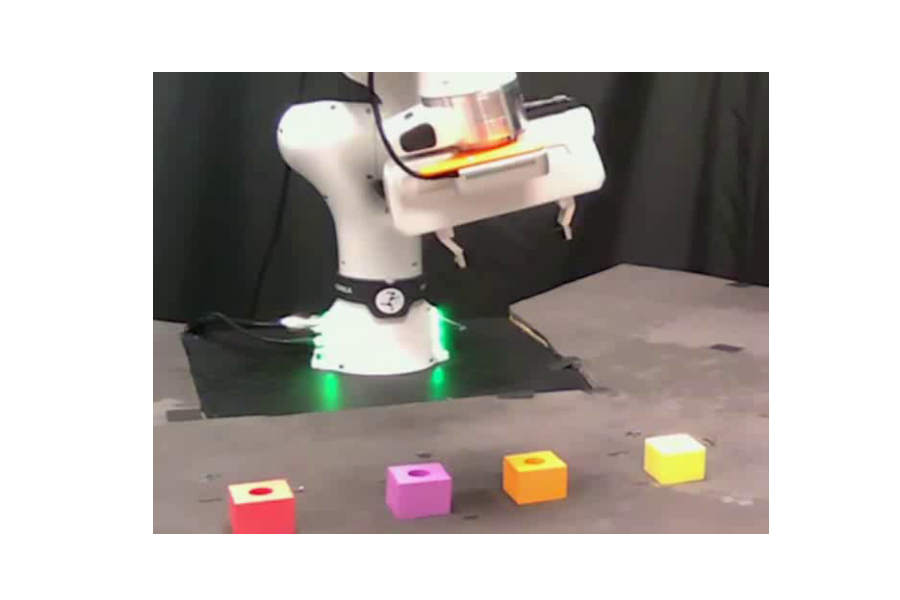

In [6]:
# take a look the first video frame
frame_idx = 0
frame = video_tensor[frame_idx]

plt.figure(figsize=(9, 6))
plt.axis("off")
plt.imshow(frame)
plt.show()

## Interactive Video Cropping

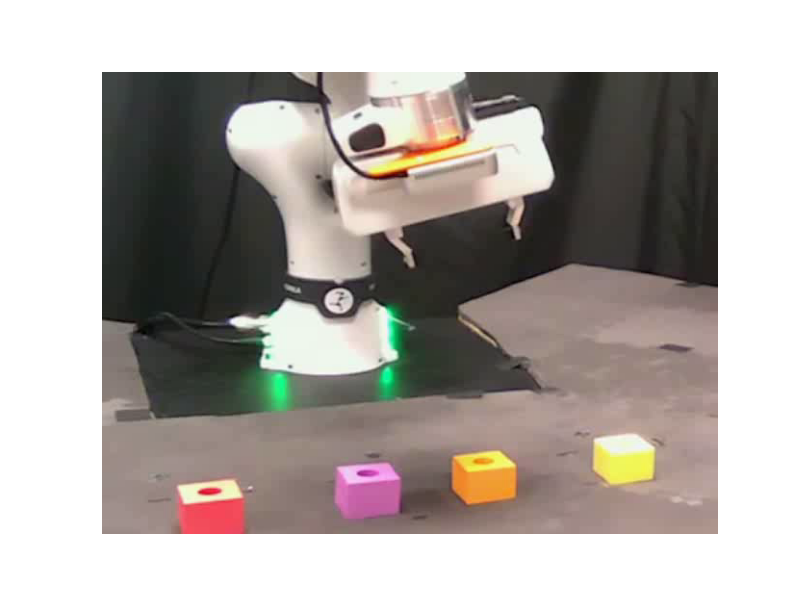

In [7]:
# Interactive cropping cell
import matplotlib.pyplot as plt
from ipywidgets import Button, HBox, VBox, IntText, Label
import numpy as np
import cv2

# State variables
crop_points = []
cropped_video_tensor = None

# Widgets
crop_btn = Button(description='Crop Video', button_style='success')
reset_crop_btn = Button(description='Reset Points', button_style='warning')
height_input = IntText(value=480, description='Height:')
width_input = IntText(value=640, description='Width:')
status_label = Label(value='Click on image to select top-left and bottom-right corners.')

# Display the first frame
fig, ax = plt.subplots(figsize=(8,6))
plt.axis('off')
ax.imshow(frame)
fig.canvas.draw()

def onclick_crop(event):
    if event.inaxes != ax:
        return
    x, y = int(event.xdata), int(event.ydata)
    crop_points.append((x, y))
    if len(crop_points) == 1:
        ax.scatter([x], [y], c='blue', marker='o', s=100, label='Top-Left')
        status_label.value = 'Now click bottom-right corner.'
    elif len(crop_points) == 2:
        ax.scatter([x], [y], c='red', marker='o', s=100, label='Bottom-Right')
        # Draw rectangle
        x1, y1 = crop_points[0]
        x2, y2 = crop_points[1]
        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='green', facecolor='none')
        ax.add_patch(rect)
        status_label.value = 'Points selected. Click Crop Video to proceed.'
    fig.canvas.draw()

cid_crop = fig.canvas.mpl_connect('button_press_event', onclick_crop)

def on_crop(b):
    global cropped_video_tensor
    if len(crop_points) != 2:
        status_label.value = 'Please select exactly 2 points.'
        return
    x1, y1 = crop_points[0]
    x2, y2 = crop_points[1]
    # Ensure x1 < x2, y1 < y2
    x_min, x_max = min(x1, x2), max(x1, x2)
    y_min, y_max = min(y1, y2), max(y1, y2)
    
    # Crop all frames
    cropped_frames = []
    for f in video_tensor:
        cropped = f[y_min:y_max, x_min:x_max]
        # Resize if specified
        h, w = height_input.value, width_input.value
        if h > 0 and w > 0:
            cropped = cv2.resize(cropped, (w, h), interpolation=cv2.INTER_LINEAR)
        cropped_frames.append(cropped)
    cropped_video_tensor = cropped_frames
    
    # Save cropped video
    cropped_video_name = "crop_original_video.mp4"
    cropped_video_path = os.path.join(dataset_path, cropped_video_name)
    try:
        vidwrite(cropped_video_path, cropped_video_tensor, framerate=target_fps, vcodec='libx264')
        status_label.value = f'Cropped video saved to: {cropped_video_path}. Rerun the loading cell to use it.'
    except Exception as e:
        try:
            vidwrite(cropped_video_path, cropped_video_tensor, framerate=target_fps, vcodec='mpeg4')
            status_label.value = f'Cropped video saved to: {cropped_video_path} (mpeg4). Rerun the loading cell to use it.'
        except Exception as e2:
            status_label.value = f'Failed to save video: {e2}'
    
    # Note: Rerun the dataset loading cell to load the cropped video

def on_reset(b):
    crop_points.clear()
    ax.clear()
    plt.axis('off')
    ax.imshow(frame)
    status_label.value = 'Click on image to select top-left and bottom-right corners.'
    fig.canvas.draw()

crop_btn.on_click(on_crop)
reset_crop_btn.on_click(on_reset)

ui_crop = HBox([height_input, width_input, crop_btn, reset_crop_btn])
display(VBox([ui_crop, status_label]))

## Interactive Mask Selection

In [8]:
from laser.preprocess.mask_generation_grounding_dino import post_process_detections, get_valid_bbox_val
from vis_utils import get_mask_one_image

# This line is necessary to avoid weird bug 
height, width, _ = frame.shape

predictor = build_sam2_video_predictor(config_path, checkpoint_path, device=device)

inference_state = predictor.init_state(video_path=video_path, target_fps=None)

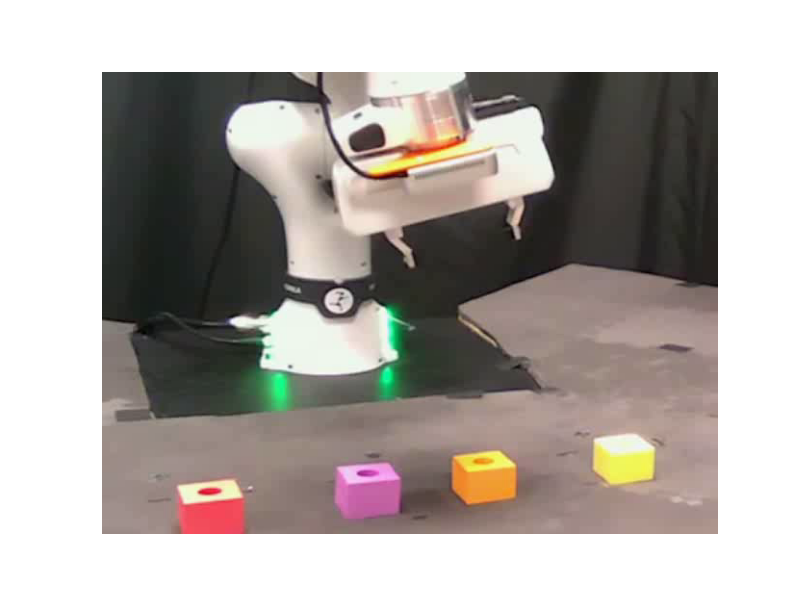

UI ready. Click to annotate. After finalizing an object the mask is shown; Obj ID auto-increments for next object.


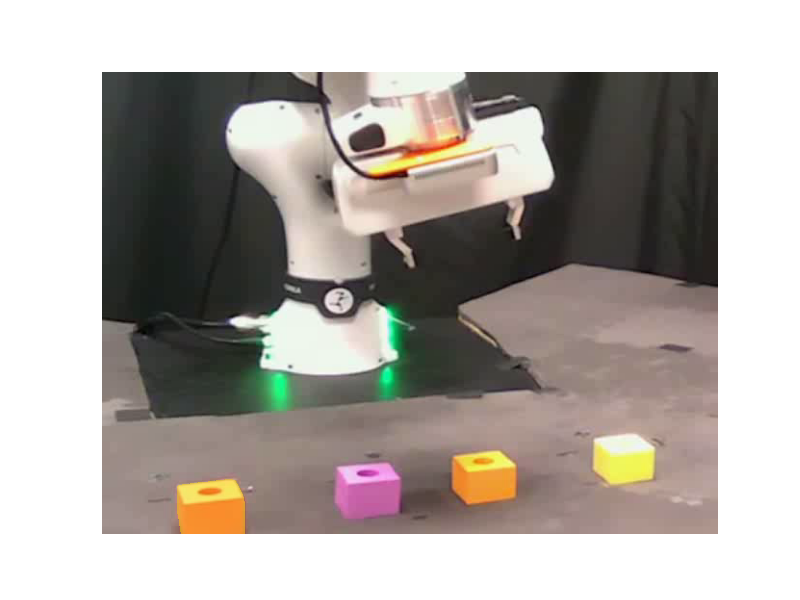

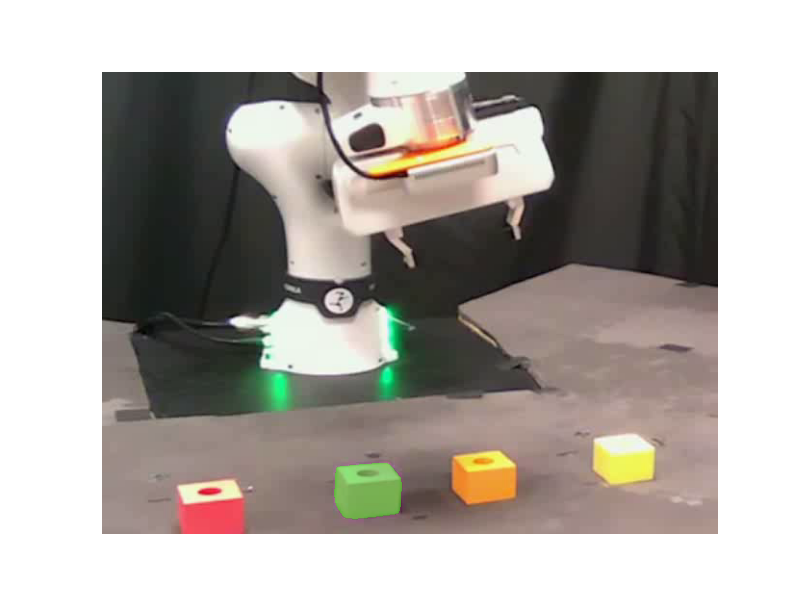

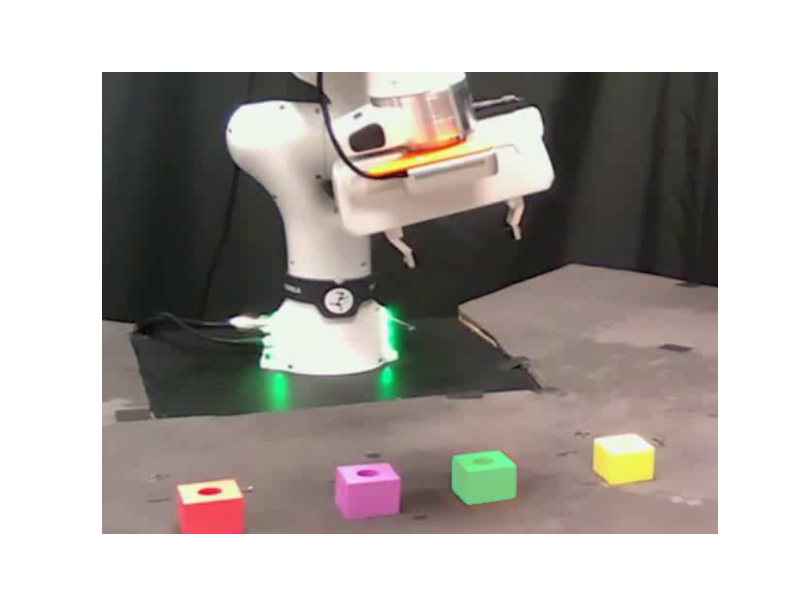

In [9]:
# Interactive annotation cell: click to add positive/negative points, finalize per-object, then finish
# Requires: ipywidgets, ipympl (for `%matplotlib widget`)
try:
    get_ipython()
    get_ipython().run_line_magic('matplotlib', 'widget')
except Exception:
    pass

from ipywidgets import ToggleButtons, Button, HBox, VBox, IntText, Label
from IPython.display import display, clear_output
import numpy as np
import os

# helper visualizers
import vis_utils
from vis_utils import show_mask, show_points

# UI state
manual_masks = {}  # {frame_id: {obj_id: mask_array}}
_points = []
_labels = []
_current_obj_id = 1

# widgets
type_toggle = ToggleButtons(options=['positive','negative'], value='positive', description='Point:')
frame_selector = IntText(value=0, description='Frame')
obj_id_selector = IntText(value=1, description='Obj ID')
final_btn = Button(description='Finalize & Add Object', button_style='success')
finish_btn = Button(description='Finish annotation', button_style='primary')
clear_btn = Button(description='Clear Points', button_style='warning')
save_btn = Button(description='Save Last Mask', button_style='info')
save_all_btn = Button(description='Save All Masks', button_style='info')
show_all_btn = Button(description='Show All Masks', button_style='')
reset_pred_btn = Button(description='Reset Predictor', button_style='danger')
status_label = Label(value='Click on image to add points. Use toggle to switch positive/negative.')
counter_label = Label(value=f'Next Obj ID: {_current_obj_id}')

# figure
fig, ax = plt.subplots(figsize=(8,6))
plt.axis('off')

def show_frame(idx):
    ax.clear()
    plt.axis('off')
    img = video_tensor[idx]
    ax.imshow(img)
    fig.canvas.draw()
    plt.show()

show_frame(frame_selector.value)

# click handler

def onclick(event):
    if event.inaxes != ax:
        return
    x, y = int(event.xdata), int(event.ydata)
    _points.append([x,y])
    lbl = 1 if type_toggle.value=='positive' else 0
    _labels.append(lbl)
    color = 'green' if lbl==1 else 'red'
    ax.scatter([x],[y], c=color, marker='*', s=150, edgecolor='white', linewidth=1.0)
    fig.canvas.draw()

cid = fig.canvas.mpl_connect('button_press_event', onclick)

_last_mask = None

# helpers

def show_all_masks_for_frame(fid):
    ax.clear(); plt.axis('off')
    ax.imshow(video_tensor[fid])
    if fid in manual_masks:
        for oid, m in manual_masks[fid].items():
            show_mask(m, ax, obj_id=oid)
    fig.canvas.draw()

# actions

def on_clear(b):
    _points.clear(); _labels.clear(); show_frame(frame_selector.value)

def on_finalize(b):
    global _last_mask, _current_obj_id
    fid = int(frame_selector.value)
    oid = int(obj_id_selector.value)
    if len(_points)==0:
        status_label.value = 'No points selected.'
        return
    pts = np.array(_points, dtype=np.float32)
    labs = np.array(_labels, dtype=np.int32)
    # call predictor
    _, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
        inference_state=inference_state,
        frame_idx=fid,
        obj_id=oid,
        points=pts,
        labels=labs,
    )
    if oid in out_obj_ids:
        idx = out_obj_ids.index(oid)
        _last_mask = (out_mask_logits[idx] > 0.0).cpu().numpy()
        # store
        manual_masks.setdefault(fid, {})[oid] = _last_mask
        status_label.value = f'Added object {oid} at frame {fid} (mask saved in memory).'
        # visualize overlay
        ax.clear(); plt.axis('off')
        ax.imshow(video_tensor[fid])
        show_mask(_last_mask, ax, obj_id=oid)
        fig.canvas.draw()
        plt.show()
        # advance counter and update selector
        _current_obj_id = max(_current_obj_id, oid+1)
        obj_id_selector.value = _current_obj_id
        counter_label.value = f'Next Obj ID: {_current_obj_id}'
        _points.clear(); _labels.clear()
    else:
        status_label.value = 'Warning: returned out_obj_ids did not include requested obj id.'


def on_save(b):
    global _last_mask
    if _last_mask is None:
        status_label.value = 'No mask to save. Finalize first.'
        return
    fid = int(frame_selector.value); oid = int(obj_id_selector.value)
    os.makedirs(mask_dir, exist_ok=True)
    p = os.path.join(mask_dir, f'mask_obj{oid}_frame{fid}.npy')
    np.save(p, _last_mask)
    status_label.value = f'Saved mask to {p}'


def on_save_all(b):
    os.makedirs(mask_dir, exist_ok=True)
    for fid, objd in manual_masks.items():
        for oid, m in objd.items():
            p = os.path.join(mask_dir, f'mask_obj{oid}_frame{fid}.npy')
            np.save(p, m)
    status_label.value = f'Saved {sum(len(v) for v in manual_masks.values())} masks to {mask_dir}'


def on_show_all(b):
    fid = int(frame_selector.value)
    show_all_masks_for_frame(fid)


def on_finish(b):
    # disconnect clicks and export manual_masks to notebook namespace
    fig.canvas.mpl_disconnect(cid)
    status_label.value = 'Annotation finished. manual_masks available in this notebook variable.'
    print('manual_masks keys:', list(manual_masks.keys()))


def on_reset_pred(b):
    try:
        predictor.reset_state(inference_state)
        status_label.value = 'Predictor state reset.'
    except Exception as e:
        status_label.value = f'Error resetting predictor: {e}'

final_btn.on_click(on_finalize)
clear_btn.on_click(on_clear)
save_btn.on_click(on_save)
save_all_btn.on_click(on_save_all)
show_all_btn.on_click(on_show_all)
finish_btn.on_click(on_finish)
reset_pred_btn.on_click(on_reset_pred)

ui1 = HBox([type_toggle, frame_selector, obj_id_selector, counter_label])
ui2 = HBox([final_btn, clear_btn, save_btn, save_all_btn, show_all_btn, finish_btn, reset_pred_btn])

ui = VBox([ui1, ui2])

display(VBox([ui, status_label]))
print('UI ready. Click to annotate. After finalizing an object the mask is shown; Obj ID auto-increments for next object.')

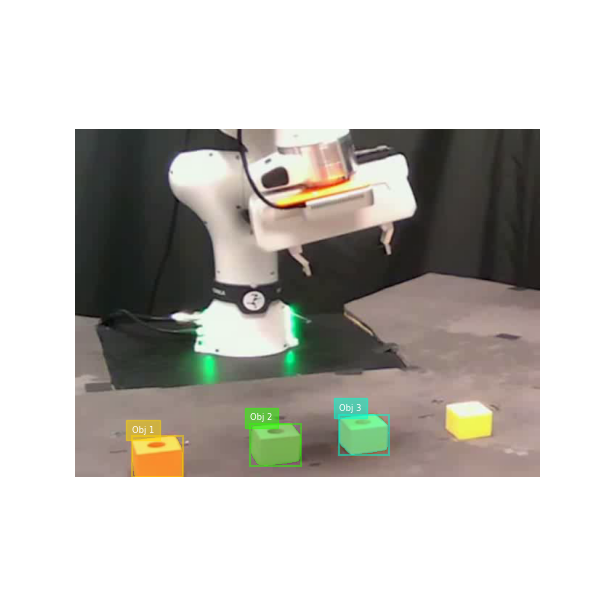

(<Figure size 600x600 with 1 Axes>, <Axes: >)

In [10]:
from vis_utils import get_mask_one_image
get_mask_one_image(frame, masks=None, frame_id=0, manual_masks=manual_masks)

## LASER Model Loading

In [11]:
import os
import torch
from huggingface_hub import hf_hub_download

# Download model from Hugging Face
repo_id = "video-fm/vine_v0"
model_filename = "laser_model_v1.pkl"

# Download the model file from Hugging Face Hub
model_path = hf_hub_download(repo_id=repo_id, filename=model_filename)

device = "cuda" if torch.cuda.is_available() else "cpu"  # Automatically use GPU if available
predicate_model = torch.load(model_path, map_location=device, weights_only=False)

In [12]:
from laser.preprocess.mask_generation_grounding_dino import mask_to_bbox

def reformat_video_segments(vid, segments, bbox_min_dim=5):
    batched_object_ids = []
    batched_pred_masks = []
    batched_pred_bboxes = []
    frame_object_pairs = []
    
    for fid, frame_info in segments.items():
        valid_objs = []
        for oid, o_mask in frame_info.items():
            if type(o_mask) == torch.Tensor:
                o_mask = o_mask.permute(1, 2, 0).numpy()
            else: 
                o_mask = o_mask.transpose(1, 2, 0)
                
            if o_mask.any():
                bbox = mask_to_bbox(o_mask)
            else:
                bbox = None
                
            # print(bbox)
            if not bbox is None:
                # print(bbox)
                x_min, y_min, x_max, y_max = bbox
                if abs(y_max - y_min) < bbox_min_dim or abs(x_max - x_min) < bbox_min_dim:
                    continue
                valid_objs.append(oid)
                batched_object_ids.append((vid, fid, oid))
                batched_pred_masks.append(o_mask)
                batched_pred_bboxes.append(bbox)
                
        for i in valid_objs:
            for j in valid_objs:
                if not i==j:
                    frame_object_pairs.append((vid, fid, (i, j)))
            
    return batched_object_ids, batched_pred_masks, batched_pred_bboxes, frame_object_pairs

In [13]:
box_threshold = 0.25
text_threshold = 0.2

In [14]:
from laser.preprocess.mask_generation_grounding_dino import  generate_masks_grounding_dino
with torch.amp.autocast('cuda', enabled=False):
    video_segments, oid_class_pred, suc = generate_masks_grounding_dino(
        grounding_model,
        box_threshold,
        text_threshold,
        predictor, 
        video_tensor, 
        video_path,  # Use original video path if processed video failed
        video_id,
        out_dir=bounding_box_dir, 
        classes_ls=classes_ls,
        target_fps=1,
        visualize=False,
        frames=None,
        max_prop_time=10,
        manual_masks=manual_masks,
        skip_grounding_dino=True)

Processing all 12 frames
Start detecting objects at time  12:26:44.389616
Skipping Grounding DINO detection, using only manual masks.
Finished detecting objects at time  12:26:44.389643
Loading inference state at time  12:26:44.389652
Number of frames:  12


Processing frames: 100%|██████████| 12/12 [00:00<00:00, 141779.29it/s]

Annotated frames:  []
Find the most dense prompt at time  12:26:47.085173
Most dense frame: 0


Start propagating objects at time  12:26:47.197448
Pass count:  0



propagate in video: 100%|██████████| 12/12 [00:01<00:00,  8.84it/s]
propagate in video: 0it [00:00, ?it/s]

Most dense frame: -1




In [15]:
# Save predicted mask/segmentation video
import matplotlib.pyplot as plt
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
import numpy as np
from vis_utils import show_mask

masked_frames = []
for fid in range(len(video_tensor)):
    fig, ax = plt.subplots(figsize=(8,6))
    ax.imshow(video_tensor[fid])
    ax.axis('off')
    if fid in video_segments:
        for oid, mask in video_segments[fid].items():
            show_mask(mask, ax, obj_id=oid)
    canvas = FigureCanvas(fig)
    canvas.draw()
    img = np.frombuffer(canvas.tostring_rgb(), dtype='uint8')
    img = img.reshape(canvas.get_width_height()[::-1] + (3,))
    masked_frames.append(img)
    plt.close(fig)

# Save the video
mask_video_path = os.path.join(dataset_path, "predicted_masks.mp4")
try:
    vidwrite(mask_video_path, masked_frames, framerate=target_fps, vcodec='libx264')
    print(f"Predicted masks video saved to: {mask_video_path}")
except Exception as e:
    try:
        vidwrite(mask_video_path, masked_frames, framerate=target_fps, vcodec='mpeg4')
        print(f"Predicted masks video saved to: {mask_video_path} (mpeg4)")
    except Exception as e2:
        print(f"Failed to save video: {e2}")

Trying to write video at:  12:27:01.507184
Trying to write video at:  12:27:01.515090
Failed to save video: [Errno 2] No such file or directory: 'ffmpeg'


In [16]:
import importlib
import laser.preprocess.mask_generation_grounding_dino

importlib.reload(laser.preprocess.mask_generation_grounding_dino)
from laser.preprocess.mask_generation_grounding_dino import mask_to_bbox

vid = 0
# Process ALL frames in the video, not just sampled frames
all_frames = list(range(len(video_tensor)))
batched_video_ids = [vid]
batched_reshaped_raw_videos = [video_tensor[fid] for fid in all_frames]
sampled_segments = {fid: video_segments[fid] for fid in all_frames if fid in video_segments}
batched_object_ids, batched_pred_masks, batched_pred_bboxes, batched_object_pairs = reformat_video_segments(vid, sampled_segments)

In [17]:
predicate_model.clip_tokenizer.pad_token_id = 0

In [18]:
predicate_model.clip_tokenizer.pad_token = "<|endoftext|>"

In [19]:
# Run inference for binary relations on the entire video
batched_pred_bboxes = [mask_to_bbox(mask) for mask in batched_pred_masks]

# Generate all possible object pairs from the detected objects
# Get unique object IDs from batched_object_ids
unique_obj_ids = set()
for vid, fid, oid in batched_object_ids:
    unique_obj_ids.add(oid)

interested_object_pairs = []
for i in unique_obj_ids:
    for j in unique_obj_ids:
        if i != j:
            interested_object_pairs.append((i, j))

print(f"Detected object IDs: {sorted(unique_obj_ids)}")
print(f"Total object pairs to analyze: {len(interested_object_pairs)}")

# Add memory check
import torch
print(f"GPU memory allocated before inference: {torch.cuda.memory_allocated('cuda:0') / 1024**3:.2f} GB")
print(f"GPU memory reserved before inference: {torch.cuda.memory_reserved('cuda:0') / 1024**3:.2f} GB")

try:
    batched_image_cate_probs, batched_image_unary_probs, batched_image_binary_probs, dummy_prob = \
        predicate_model(
            batched_video_ids=batched_video_ids,
            batched_videos=batched_reshaped_raw_videos,
            batched_masks=batched_pred_masks,  # batched_object_ids * video_height * video_width
            batched_bboxes=batched_pred_bboxes,  # batched_object_ids * dict<bboxes>
            batched_names=[["object"]],  # Dataset-wise categorical labels
            batched_object_ids=batched_object_ids,  # [video_id, frame_id, object_id]
            batched_unary_kws=[[]],  # Dataset-wise unary predicate labels
            batched_binary_kws=[binary_classes],  # Dataset-wise binary predicate labels
            batched_obj_pairs=batched_object_pairs,  # Ground truth binary relations
            batched_video_splits=[0],  # [number of videos]
            batched_binary_predicates=[None],  # None indicates inference time
        )
    print("Inference completed successfully.")
except Exception as e:
    print(f"Error during inference: {e}")
    import traceback
    traceback.print_exc()

Detected object IDs: [0, 1, 2]
Total object pairs to analyze: 6
GPU memory allocated before inference: 7.58 GB
GPU memory reserved before inference: 8.85 GB
Inference completed successfully.


In [20]:
def format_binary_probs(batched_binary_probs, topk=3):
    new_batched_cate_probs = {}
    for vid, vid_pred in enumerate(batched_binary_probs):
        new_batched_cate_probs[vid] = {}
        sorted_obj_preds = {}
        for (fid, obj_tp, rel), prob in vid_pred.items():
            if not fid in sorted_obj_preds:
                sorted_obj_preds[fid] = {}
            if not fid in new_batched_cate_probs[vid]:
                new_batched_cate_probs[vid][fid] = {}
            if not obj_tp in sorted_obj_preds[fid]:
                sorted_obj_preds[fid][obj_tp] = []
            sorted_obj_preds[fid][obj_tp].append((prob, rel))
        
        for fid in sorted_obj_preds:
            for obj_tp in sorted_obj_preds[fid]:
                top_preds = sorted(sorted_obj_preds[fid][obj_tp], reverse=True)[:topk]
                str_info = []
                for (prob, rel) in top_preds:
                    str_info.append(f"{prob:.2f}::{rel}")
                top_str = '\n'.join(str_info)
                new_batched_cate_probs[vid][fid][obj_tp] = top_str
        
    return new_batched_cate_probs

topk = 3
formatted_batched_binary_probs = format_binary_probs(batched_image_binary_probs)

In [21]:
formatted_batched_binary_probs

{0: {0: {(0, 1): '0.51::left\n0.24::on\n0.24::holding',
   (0, 2): '0.60::on\n0.36::left\n0.03::holding',
   (1, 0): '0.51::left\n0.24::on\n0.24::holding',
   (1, 2): '0.60::holding\n0.32::left\n0.08::on',
   (2, 0): '0.60::on\n0.36::left\n0.03::holding',
   (2, 1): '0.90::holding\n0.08::left\n0.01::on'},
  1: {(0, 1): '0.60::left\n0.22::on\n0.17::holding',
   (0, 2): '0.78::on\n0.20::left\n0.02::holding',
   (1, 0): '0.60::left\n0.22::on\n0.17::holding',
   (1, 2): '0.49::left\n0.49::holding\n0.01::on',
   (2, 0): '0.78::on\n0.20::left\n0.02::holding',
   (2, 1): '0.55::holding\n0.43::left\n0.01::on'},
  2: {(0, 1): '0.54::left\n0.26::holding\n0.20::on',
   (0, 2): '0.57::on\n0.39::left\n0.04::holding',
   (1, 0): '0.54::left\n0.26::holding\n0.20::on',
   (1, 2): '0.84::left\n0.13::holding\n0.03::on',
   (2, 0): '0.57::on\n0.39::left\n0.04::holding',
   (2, 1): '0.74::left\n0.16::on\n0.10::holding'},
  3: {(0, 1): '0.45::left\n0.31::on\n0.24::holding',
   (0, 2): '0.52::on\n0.46::left

## Visualization for Whole Video Binary Masks and Relations

In [22]:
# Reload the vis_utils
import importlib
import vis_utils

importlib.reload(vis_utils)
from vis_utils import get_binary_mask_one_image

# Create output directory for video results within the dataset folder
import os
video_output_dir = os.path.join(dataset_path, 'inference_output')
os.makedirs(video_output_dir, exist_ok=True)

# Process each frame in the video
for fid in range(len(video_tensor)):
    if fid not in video_segments:
        print(f"No segments for frame {fid}, skipping...")
        continue
        
    # Get the binary mask visualization for this frame
    fig, ax = get_binary_mask_one_image(
        video_tensor[fid], 
        video_segments[fid], 
        rel_pred_ls=formatted_batched_binary_probs[0].get(fid, {})
    )
    
    # Save the frame
    output_path = os.path.join(video_output_dir, f"frame_{fid:04d}.png")
    fig.savefig(output_path, bbox_inches='tight', dpi=150)
    plt.close(fig)
    
    if fid % 10 == 0:
        print(f"Processed frame {fid}/{len(video_tensor)}")

print(f"Video processing complete. Results saved to {video_output_dir}")

Processed frame 0/12
Processed frame 10/12
Video processing complete. Results saved to /scratch/kpham34/cross_model_learning_based_robot_control/external/datasets/franka_recording_example_1_file-000/inference_output


In [23]:
# Optional: Create a video from the processed frames
import cv2
import glob

frame_files = sorted(glob.glob(os.path.join(video_output_dir, "frame_*.png")))
if frame_files:
    # Read first frame to get dimensions
    first_frame = cv2.imread(frame_files[0])
    height, width, _ = first_frame.shape
    
    # Create video writer
    video_output_path = os.path.join(dataset_path, "binary_masks_relations.mp4")
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(video_output_path, fourcc, target_fps, (width, height))
    
    for frame_file in frame_files:
        frame = cv2.imread(frame_file)
        out.write(frame)
    
    out.release()
    print(f"Video created: {video_output_path}")
else:
    print("No frames found to create video")

Video created: /scratch/kpham34/cross_model_learning_based_robot_control/external/datasets/franka_recording_example_1_file-000/binary_masks_relations.mp4


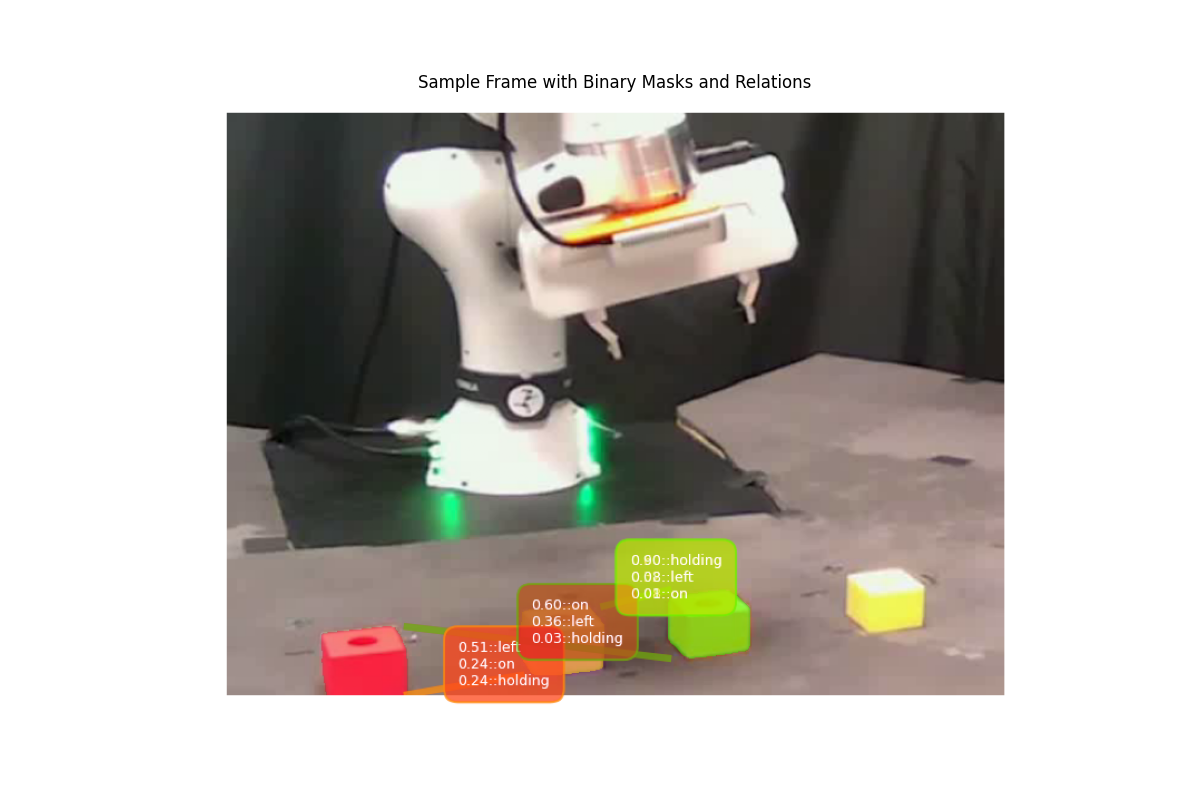

In [24]:
# Display a sample frame result
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

sample_frame_path = os.path.join(video_output_dir, "frame_0000.png")
if os.path.exists(sample_frame_path):
    img = mpimg.imread(sample_frame_path)
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Sample Frame with Binary Masks and Relations')
    plt.show()
else:
    print("Sample frame not found")